<a href="https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ezgicode/FlyRAnk-AI/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

The audit uses the same public-safe March 2026 page-level feature frame as the capstone: signals from 1–15 March are measured before the later outcome window of 16–31 March. Impressions, clicks, and CTR are expected to have heavy tails, so the analysis uses log views, bins, rates, and medians. Pseudonymized IDs are retained only to build one page-level row and are not treated as signals.

Feature-frame rows: 77,540
Later-window decline proxy rate: 28.6%


,count,mean,std,min,1%,25%,50%,75%,99%,max
prior_15d_impressions,77540.0,1619.912845,3576.667939,100.000000,103.000000,238.000000,576.000000,1540.000000,16212.980000,161575.000000
prior_15d_clicks,77540.0,4.885930,18.225552,0.000000,0.000000,0.000000,1.000000,4.000000,59.000000,2395.000000
prior_15d_avg_position,77540.0,12.402142,12.851990,0.013889,0.960742,4.226398,7.263206,15.909307,63.132115,119.429688
prior_15d_ctr,77540.0,0.002921,0.004739,0.000000,0.000000,0.000000,0.001340,0.004202,0.020703,0.213592
prior_15d_active_days,77540.0,14.242662,1.988768,1.000000,4.000000,15.000000,15.000000,15.000000,15.000000,15.000000


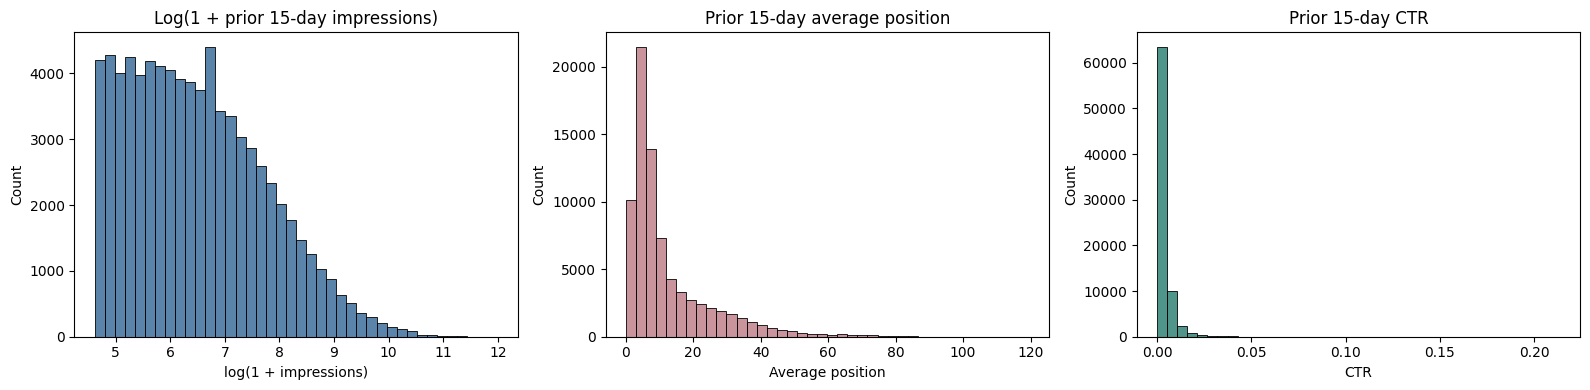

In [ ]:
# Same public-safe data boundary as the capstone:
# feature window = 1–15 March 2026
# later outcome window = 16–31 March 2026

!pip -q install duckdb seaborn

import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("Add your Hugging Face read token as the Colab Secret named HF_TOKEN.")

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute(
    f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{REL}/fact_content_daily_performance"
MARCH = f"read_parquet('{FACT}/month=2026-03/*.parquet')"

feature_sql = f"""
WITH march_page_days AS (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position
    FROM {MARCH}
    WHERE gsc_data_available IS TRUE
      AND report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-31'
),
page_windows AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(CASE WHEN report_date <= DATE '2026-03-15'
                 THEN gsc_impressions ELSE 0 END) AS prior_15d_impressions,

        SUM(CASE WHEN report_date <= DATE '2026-03-15'
                 THEN gsc_clicks ELSE 0 END) AS prior_15d_clicks,

        SUM(CASE WHEN report_date <= DATE '2026-03-15'
                 THEN gsc_sum_position ELSE 0 END)
        / NULLIF(
            SUM(CASE WHEN report_date <= DATE '2026-03-15'
                     THEN gsc_impressions ELSE 0 END),
            0
        ) AS prior_15d_avg_position,

        COUNT(DISTINCT CASE WHEN report_date <= DATE '2026-03-15'
                            THEN report_date END) AS prior_15d_active_days,

        SUM(CASE WHEN report_date >= DATE '2026-03-16'
                 THEN gsc_impressions ELSE 0 END) AS next_16d_impressions
    FROM march_page_days
    GROUP BY client_hash_id, content_hash_id
)
SELECT *
FROM page_windows
WHERE prior_15d_impressions >= 100
"""

feature_frame = con.sql(feature_sql).df()

feature_frame["prior_15d_ctr"] = (
    feature_frame["prior_15d_clicks"]
    / feature_frame["prior_15d_impressions"]
)

feature_frame["is_next_15d_declining"] = (
    feature_frame["next_16d_impressions"]
    <= 0.80 * feature_frame["prior_15d_impressions"]
).astype(int)

signal_columns = [
    "prior_15d_impressions",
    "prior_15d_clicks",
    "prior_15d_avg_position",
    "prior_15d_ctr",
    "prior_15d_active_days",
]

print(f"Feature-frame rows: {len(feature_frame):,}")
print(
    "Later-window decline proxy rate: "
    f"{feature_frame['is_next_15d_declining'].mean():.1%}"
)

display(
    feature_frame[signal_columns]
    .describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99])
    .T
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(
    np.log1p(feature_frame["prior_15d_impressions"]),
    bins=40,
    ax=axes[0],
    color="#245b8f",
)
axes[0].set_title("Log(1 + prior 15-day impressions)")
axes[0].set_xlabel("log(1 + impressions)")

sns.histplot(
    feature_frame["prior_15d_avg_position"],
    bins=40,
    ax=axes[1],
    color="#b8717b",
)
axes[1].set_title("Prior 15-day average position")
axes[1].set_xlabel("Average position")

sns.histplot(
    feature_frame["prior_15d_ctr"],
    bins=40,
    ax=axes[2],
    color="#167262",
)
axes[2].set_title("Prior 15-day CTR")
axes[2].set_xlabel("CTR")

plt.tight_layout()
plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Three measured associations are tested below. A verdict means only that the observed pattern in this historical slice is consistent, opposite, or mixed relative to the stated expectation. It does not establish a causal ranking factor or a guaranteed editorial outcome.

Signal 1 — Better observed position is associated with higher CTR: CONFIRMED


,position_band,pages,median_ctr,later_decline_rate
0,1–3,10148,0.002356,0.255420
1,4–10,38848,0.001894,0.282048
2,11–20,13318,0.000610,0.258522
3,21–50,13517,0.000000,0.343197
4,51+,1709,0.000000,0.304857


Signal 2 — Prior visibility alone and the later decline proxy: DIRECTIONAL


,impression_quintile,pages,median_impressions,median_ctr,later_decline_rate
0,"(99.999, 199.0]",15529,141.0,0.000000,0.294095
1,"(199.0, 401.0]",15504,283.0,0.000000,0.289667
2,"(401.0, 844.0]",15501,576.0,0.001730,0.286627
3,"(844.0, 1977.0]",15500,1224.0,0.002165,0.262968
4,"(1977.0, 161575.0]",15506,3764.0,0.002052,0.295047


Signal 3 — Prior CTR and the later decline proxy: DIRECTIONAL


,ctr_quintile,pages,median_ctr,median_position,later_decline_rate
0,"(-0.001, 0.000272]",31016,0.000000,9.772640,0.336697
1,"(0.000272, 0.00225]",15508,0.001340,6.489935,0.339502
2,"(0.00225, 0.00494]",15509,0.003442,6.144504,0.231672
3,"(0.00494, 0.214]",15507,0.007812,5.635496,0.183852


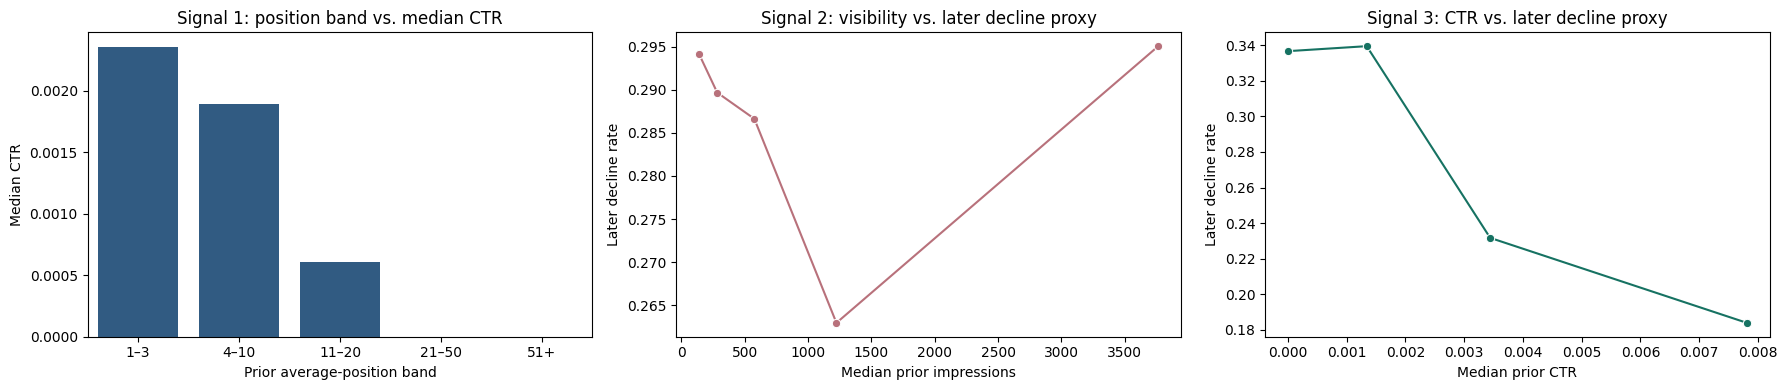

In [ ]:
audit = feature_frame.copy()

# Signal 1: average position and CTR
audit["position_band"] = pd.cut(
    audit["prior_15d_avg_position"],
    bins=[0, 3, 10, 20, 50, np.inf],
    labels=["1–3", "4–10", "11–20", "21–50", "51+"],
    include_lowest=True,
)

position_ctr = (
    audit.groupby("position_band", observed=False)
    .agg(
        pages=("content_hash_id", "size"),
        median_ctr=("prior_15d_ctr", "median"),
        later_decline_rate=("is_next_15d_declining", "mean"),
    )
    .reset_index()
)

# Signal 2: prior visibility and later decline proxy
audit["impression_quintile"] = pd.qcut(
    audit["prior_15d_impressions"],
    q=5,
    duplicates="drop",
)

visibility_decline = (
    audit.groupby("impression_quintile", observed=False)
    .agg(
        pages=("content_hash_id", "size"),
        median_impressions=("prior_15d_impressions", "median"),
        median_ctr=("prior_15d_ctr", "median"),
        later_decline_rate=("is_next_15d_declining", "mean"),
    )
    .reset_index()
)

# Signal 3: prior CTR and later decline proxy
audit["ctr_quintile"] = pd.qcut(
    audit["prior_15d_ctr"],
    q=5,
    duplicates="drop",
)

ctr_decline = (
    audit.groupby("ctr_quintile", observed=False)
    .agg(
        pages=("content_hash_id", "size"),
        median_ctr=("prior_15d_ctr", "median"),
        median_position=("prior_15d_avg_position", "median"),
        later_decline_rate=("is_next_15d_declining", "mean"),
    )
    .reset_index()
)

signal_1 = (
    "CONFIRMED"
    if position_ctr["median_ctr"].iloc[0] > position_ctr["median_ctr"].iloc[-1]
    else "OPPOSITE"
)

visibility_range = (
    visibility_decline["later_decline_rate"].max()
    - visibility_decline["later_decline_rate"].min()
)
signal_2 = "MIXED" if visibility_range < 0.02 else "DIRECTIONAL"

ctr_range = (
    ctr_decline["later_decline_rate"].max()
    - ctr_decline["later_decline_rate"].min()
)
signal_3 = "MIXED" if ctr_range < 0.02 else "DIRECTIONAL"

print(f"Signal 1 — Better observed position is associated with higher CTR: {signal_1}")
display(position_ctr)

print(f"Signal 2 — Prior visibility alone and the later decline proxy: {signal_2}")
display(visibility_decline)

print(f"Signal 3 — Prior CTR and the later decline proxy: {signal_3}")
display(ctr_decline)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.barplot(
    data=position_ctr,
    x="position_band",
    y="median_ctr",
    ax=axes[0],
    color="#245b8f",
)
axes[0].set_title("Signal 1: position band vs. median CTR")
axes[0].set_xlabel("Prior average-position band")
axes[0].set_ylabel("Median CTR")

sns.lineplot(
    data=visibility_decline,
    x="median_impressions",
    y="later_decline_rate",
    marker="o",
    ax=axes[1],
    color="#b8717b",
)
axes[1].set_title("Signal 2: visibility vs. later decline proxy")
axes[1].set_xlabel("Median prior impressions")
axes[1].set_ylabel("Later decline rate")

sns.lineplot(
    data=ctr_decline,
    x="median_ctr",
    y="later_decline_rate",
    marker="o",
    ax=axes[2],
    color="#167262",
)
axes[2].set_title("Signal 3: CTR vs. later decline proxy")
axes[2].set_xlabel("Median prior CTR")
axes[2].set_ylabel("Later decline rate")

plt.tight_layout()
plt.show()

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

The action-playbook queue uses a `visible_low_ctr_opportunity` reason code. This test checks the rule’s narrow assumption: among pages with meaningful visibility and comparable position bands, pages flagged for low CTR should have materially lower observed CTR than their peers. It does not claim that a title or snippet edit will cause improvement.

In [ ]:
flag_audit = feature_frame.copy()

# Keep pages with enough observed visibility for a meaningful CTR comparison.
flag_audit = flag_audit[
    (flag_audit["prior_15d_impressions"] >= 500)
    & (flag_audit["prior_15d_avg_position"] > 0)
    & (flag_audit["prior_15d_avg_position"] <= 20)
].copy()

flag_audit["position_band"] = pd.cut(
    flag_audit["prior_15d_avg_position"],
    bins=[0, 3, 10, 20],
    labels=["1–3", "4–10", "11–20"],
    include_lowest=True,
)

# Compare CTR only within position bands.
flag_audit["band_ctr_q25"] = (
    flag_audit.groupby("position_band", observed=False)["prior_15d_ctr"]
    .transform(lambda s: s.quantile(0.25))
)

flag_audit["visible_low_ctr_opportunity"] = (
    flag_audit["prior_15d_ctr"] <= flag_audit["band_ctr_q25"]
)

flag_summary = (
    flag_audit.groupby("visible_low_ctr_opportunity")
    .agg(
        pages=("content_hash_id", "size"),
        median_impressions=("prior_15d_impressions", "median"),
        median_position=("prior_15d_avg_position", "median"),
        median_ctr=("prior_15d_ctr", "median"),
        later_decline_rate=("is_next_15d_declining", "mean"),
    )
    .reset_index()
)

display(flag_summary)

flagged_ctr = flag_summary.loc[
    flag_summary["visible_low_ctr_opportunity"], "median_ctr"
].iloc[0]

unflagged_ctr = flag_summary.loc[
    ~flag_summary["visible_low_ctr_opportunity"], "median_ctr"
].iloc[0]

flag_verdict = (
    "CONFIRMED"
    if flagged_ctr < unflagged_ctr
    else "MIXED"
)

print(
    "Flag-linked verdict: "
    f"{flag_verdict}. The flag identifies relatively low observed CTR within "
    "comparable visible position bands; a human must still inspect intent, "
    "SERP context, content quality, and expected value."
)

,visible_low_ctr_opportunity,pages,median_impressions,median_position,median_ctr,later_decline_rate
0,False,25653,1405.0,5.013350,0.003404,0.204849
1,True,8556,1155.0,5.672909,0.000000,0.390486


Flag-linked verdict: CONFIRMED. The flag identifies relatively low observed CTR within comparable visible position bands; a human must still inspect intent, SERP context, content quality, and expected value.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The observed position-to-CTR pattern supports using position as review context, not as proof of a search-engine rule. Visibility and CTR patterns should help prioritize a limited human-review queue, but they do not tell an editor why a page underperforms or which edit will work. A FlyRank editor should review intent, current SERP context, freshness, content quality, cost, and expected value before changing anything.

In [ ]:
practice_summary = pd.DataFrame(
    [
        {
            "decision_support_use": "Prioritize manual inspection of visible pages with unusually low CTR within comparable position bands.",
            "human_check_required": "Search intent, current SERP, freshness, quality, cost, and expected value.",
            "must_not_be_automated": "Publishing, rewriting, deleting, merging, canonicalising, or changing titles and internal links.",
        },
        {
            "decision_support_use": "Use the later-window decline proxy as a directional ranking signal only.",
            "human_check_required": "Confirm the page has a credible, actionable opportunity before allocating editorial effort.",
            "must_not_be_automated": "Treating a score or signal as proof that a page will decline or recover.",
        },
    ]
)

display(practice_summary)

,decision_support_use,human_check_required,must_not_be_automated
0,Prioritize manual inspection of visible pages ...,"Search intent, current SERP, freshness, qualit...","Publishing, rewriting, deleting, merging, cano..."
1,Use the later-window decline proxy as a direct...,"Confirm the page has a credible, actionable op...",Treating a score or signal as proof that a pag...


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.